Volume required for 90.0% conversion in PFR is 500.01L
Volume required for 90.0% conversion in CSTR is 5000.00L
Volume required for CSTR is 10 times the volume required for PFR for achieving 90.0% conversion
Hence, PFR offers a substantial reduction in reactor volume.


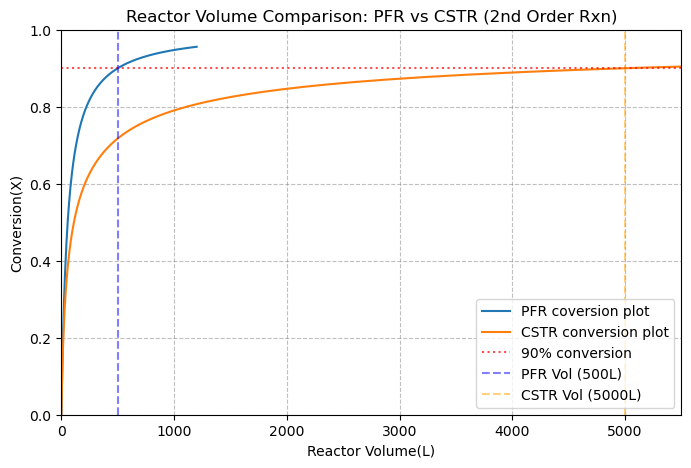

Reactor construction cost incurred for a PFR is ₹20,000,276, while for a CSTR it is ₹200,000,000Rs


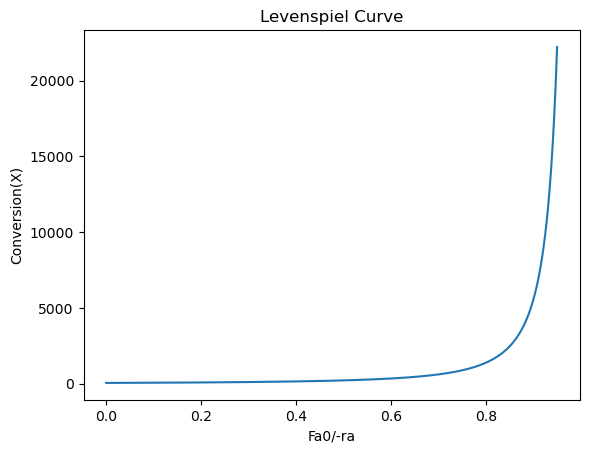

In [1]:
#Mini Project
##PFR(Plug flow reactor) is to be designed for a second order irreversible reaction.
#For a given set of feed data and rate constant, the primary objective is to determine whether a CSTR or a PFR provides the lesser volume for a required conversion.
#This approach is pertinent to ensure economical feasibility in reactor design as generally the capital cost scales considerabely with reactor tank volume.
## Assumptions
#Steady-state operation
#Constant density
#Isothermal reactor
#Second-order irreversible kinetics
#No pressure drop
#Constant volumetric flow rate
##Governing Equations are -ra=k*Ca^2, dFa/dV=ra and Fa=Fa0(1-X).
##Given Values
k = 0.45 #L/mol·min
CA0 = 2 #mol/L
FA0 = 100 #mol/min
#importing libraries 
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
##Solving the differential equation dX/dV=-ra/Fa0
def pfr(X,V):
    CA=CA0*(1-X)
    ra=-k*CA**2
    return -ra/FA0
V_PFR=np.linspace(0,1200,300)
X0=0
Ans=odeint(pfr,X0,V_PFR)
X_pfr=Ans.flatten()
##Calculating CSTR Volume for these given conditions for direct comparison
X_cstr=np.linspace(0,0.95,300)
CA=CA0*(1-X_cstr)
ra=-k*CA**2
V_CSTR=np.round(FA0*X_cstr/-ra,2)
##Reactor Volume required to achieve 90% conversion, CSTR vs PFR.#
#PFR
target_conversion=0.90
V_for_90_pfr=np.interp(target_conversion,X_pfr,V_PFR)
print(f'Volume required for {target_conversion*100}% conversion in PFR is {V_for_90_pfr:.2f}L')
#CSTR
CA_TC=CA0*(1-target_conversion)
ra_cstr_TC=-k*CA_TC**2
V_for_90_cstr=FA0*target_conversion/-ra_cstr_TC
print(f'Volume required for {target_conversion*100}% conversion in CSTR is {V_for_90_cstr:.2f}L')
V_ratio=V_for_90_cstr/V_for_90_pfr
print(f'Volume required for CSTR is {V_ratio:.0f} times the volume required for PFR for achieving {target_conversion*100}% conversion')
if V_ratio > 1.5:
    print("Hence, PFR offers a substantial reduction in reactor volume.")
else:
    print("The benefit of using a PFR is relatively modest.")
##Plotting the V vs X curve
fig,ax=plt.subplots(figsize=(8,5))
ax.plot(V_PFR,X_pfr,label='PFR coversion plot')
ax.plot(V_CSTR,X_cstr,label='CSTR conversion plot')
ax.set_title('Reactor Volume Comparison: PFR vs CSTR (2nd Order Rxn)')
ax.set_xlabel('Reactor Volume(L)')
ax.set_ylabel('Conversion(X)')
ax.axhline(target_conversion, color='red', linestyle=':', alpha=0.7, label=f'{(target_conversion*100):.0f}% conversion')
ax.axvline(V_for_90_pfr, color='blue', linestyle='--', alpha=0.5, label=f'PFR Vol ({V_for_90_pfr:.0f}L)')
ax.axvline(V_for_90_cstr, color='orange', linestyle='--', alpha=0.5, label=f'CSTR Vol ({V_for_90_cstr:.0f}L)')
ax.grid(True, linestyle='--', color='grey',alpha=0.5)
ax.set_xlim(0,5500)
ax.set_ylim(0,1)
ax.legend(loc='lower right')
plt.show()
##Comparing economical feasibility by computing reactor construction capital cost assuming 40000Rs/L of construction cost. 
cons_cost=40000
cost_pfr=V_for_90_pfr*cons_cost
cost_cstr=V_for_90_cstr*cons_cost
print(f'Reactor construction cost incurred for a PFR is ₹{cost_pfr:,.0f}, while for a CSTR it is ₹{cost_cstr:,.0f}Rs')
##Levenspiel Plot
Levenspiel = FA0/-ra
plt.plot(X_cstr,Levenspiel)
plt.title('Levenspiel Curve')
plt.xlabel('Fa0/-ra')
plt.ylabel('Conversion(X)')
plt.show()